### **Importing Libraries**

- `pandas` for building and manipulating dataframes
- `numpy` for underlying numeric operations (pandas is built on top of it)
- `matplotlib.pyplot` for plotting distributions later on
- `leaguedashplayerstats` from `nba_api` — the bulk endpoint used to pull season-level player stats

In [43]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
from nba_api.stats.endpoints import (
    leaguedashplayerstats, playerawards, leaguedashplayerclutch, leagueseasonmatchups,
)
from nba_api.stats.static import players as players_module

### **Display Settings**

- Overrides pandas' default truncation so all columns and rows print in full when displaying a dataframe, instead of collapsing wide/long tables with `...`
- Purely a notebook convenience — does not affect the underlying data

In [44]:
pd.set_option("display.max_columns", None, "display.max_rows", None)

### **Pull Base Season Stats (Totals)**

- Pulls `Base` mode stats — box-score counting stats (FGA, FGM, MIN, GP, PLUS_MINUS, etc.) — not the advanced metrics
- `per_mode_detailed="Totals"` returns full-season totals per player, not per-game averages — this matters later when judging how much evidence (e.g. shot attempts) backs a stat like TS%
- `measure_type_detailed_defense="Base"` — despite the parameter name, this selects the stat *category* ("Base"), not something defense-specific; it accepts other values like `Advanced`, `Scoring`, `Usage`, `Defense`, etc.

In [45]:
leaguestats_base_df = leaguedashplayerstats.LeagueDashPlayerStats(
    season="2025-26",
    season_type_all_star="Regular Season", 
    per_mode_detailed="Totals",
    measure_type_detailed_defense="Base",

).get_data_frames()[0]

### **Quick Visual Spot-Check**

- Pulls 5 random rows to eyeball the data before doing any formal profiling

In [46]:
leaguestats_base_df.sample(5)

,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,AGE,GP,W,L,W_PCT,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,NBA_FANTASY_PTS,DD2,TD3,WNBA_FANTASY_PTS,GP_RANK,W_RANK,L_RANK,W_PCT_RANK,MIN_RANK,FGM_RANK,FGA_RANK,FG_PCT_RANK,FG3M_RANK,FG3A_RANK,FG3_PCT_RANK,FTM_RANK,FTA_RANK,FT_PCT_RANK,OREB_RANK,DREB_RANK,REB_RANK,AST_RANK,TOV_RANK,STL_RANK,BLK_RANK,BLKA_RANK,PF_RANK,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK,NBA_FANTASY_PTS_RANK,DD2_RANK,TD3_RANK,WNBA_FANTASY_PTS_RANK,TEAM_COUNT
515,201959,Taj Gibson,Taj,1610612763,MEM,41.0,10,1,9,0.100,96.873333,12,26,0.462,3,6,0.500,7,8,0.875,11,16,27,6,1,2,1,4,14,7,34,-7,83.4,0,0,76.0,500,549,116,562,504,503,504,271,460,488,13,468,477,87,431,489,478,515,545,516,493,125,98,485,502,280,501,284,38,506,1
495,1630703,Scoot Henderson,Scoot,1610612757,POR,22.0,30,18,12,0.600,747.830000,143,342,0.418,57,162,0.352,84,100,0.840,18,62,80,112,73,27,9,18,85,91,427,53,726.0,0,0,748.0,410,325,152,174,334,281,258,428,224,227,250,183,208,149,379,377,383,212,173,300,315,313,310,200,266,154,315,284,38,307,1
194,203084,Harrison Barnes,Harrison,1610612759,SAS,34.0,77,57,20,0.740,1986.475000,262,575,0.456,139,358,0.388,102,123,0.829,62,151,213,148,61,50,12,21,85,103,765,329,1367.6,0,0,1389.0,37,6,251,58,83,149,149,291,57,72,125,148,156,172,152,225,206,152,224,176,277,346,310,174,142,37,173,284,38,159,1
553,1631213,Tyrese Martin,Tyrese,1610612755,PHI,27.0,46,12,34,0.261,776.610000,109,277,0.394,53,165,0.321,19,28,0.679,34,82,116,78,40,25,6,8,33,24,290,-181,599.2,0,0,599.0,324,395,449,480,330,325,301,492,238,226,357,394,388,449,283,340,336,292,309,314,375,195,168,395,329,512,343,284,38,337,2
579,1630533,Ziaire Williams,Ziaire,1610612751,BKN,24.0,56,13,43,0.232,1281.266667,184,433,0.425,86,251,0.343,119,140,0.850,30,104,134,60,59,76,21,20,116,115,573,-282,1055.8,0,0,1047.0,247,384,527,505,218,231,216,400,150,140,279,126,137,132,306,300,309,329,235,61,197,337,384,156,202,549,241,284,38,233,1


### **Pull Advanced Season Stats (Totals)**

- Same endpoint and season as above, but `measure_type_detailed_defense="Advanced"` — returns the derived/efficiency metrics (TS_PCT, EFG_PCT, USG_PCT, NET_RATING, PIE) that aren't available in `Base` mode
- Result: two separate dataframes, each holding a different subset of the 6 core metrics for this project

In [47]:
leaguestats_df = leaguedashplayerstats.LeagueDashPlayerStats(
    season="2025-26",
    season_type_all_star="Regular Season", 
    per_mode_detailed="Totals",
    measure_type_detailed_defense="Advanced",

).get_data_frames()[0]

### **Structure**

- `.shape` — row and column counts, to sanity-check the pull returned a believable number of players
- `.dtypes` — confirms each column's data type; a numeric column showing up as `object` would flag a hidden non-numeric value breaking calculations later
- `.sample(5)` — another visual spot-check, this time on the Advanced dataframe specifically

In [48]:
display(leaguestats_df.shape)
display(leaguestats_df.dtypes)
display(leaguestats_df['GP'].describe())
display(leaguestats_df.sample(5))

(582, 79)

PLAYER_ID                    int64
PLAYER_NAME                    str
NICKNAME                       str
TEAM_ID                      int64
TEAM_ABBREVIATION              str
AGE                        float64
GP                           int64
W                            int64
L                            int64
W_PCT                      float64
MIN                        float64
E_OFF_RATING               float64
OFF_RATING                 float64
sp_work_OFF_RATING         float64
E_DEF_RATING               float64
DEF_RATING                 float64
sp_work_DEF_RATING         float64
E_NET_RATING               float64
NET_RATING                 float64
sp_work_NET_RATING         float64
AST_PCT                    float64
AST_TO                     float64
AST_RATIO                  float64
OREB_PCT                   float64
DREB_PCT                   float64
REB_PCT                    float64
TM_TOV_PCT                 float64
E_TOV_PCT                  float64
EFG_PCT             

count    582.000000
mean      45.792096
std       24.937300
min        1.000000
25%       23.000000
50%       51.000000
75%       67.750000
max       82.000000
Name: GP, dtype: float64

,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,AGE,GP,W,L,W_PCT,MIN,E_OFF_RATING,OFF_RATING,sp_work_OFF_RATING,E_DEF_RATING,DEF_RATING,sp_work_DEF_RATING,E_NET_RATING,NET_RATING,sp_work_NET_RATING,AST_PCT,AST_TO,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,E_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,sp_work_PACE,PIE,POSS,FGM,FGA,FGM_PG,FGA_PG,FG_PCT,GP_RANK,W_RANK,L_RANK,W_PCT_RANK,MIN_RANK,E_OFF_RATING_RANK,OFF_RATING_RANK,sp_work_OFF_RATING_RANK,E_DEF_RATING_RANK,DEF_RATING_RANK,sp_work_DEF_RATING_RANK,E_NET_RATING_RANK,NET_RATING_RANK,sp_work_NET_RATING_RANK,AST_PCT_RANK,AST_TO_RANK,AST_RATIO_RANK,OREB_PCT_RANK,DREB_PCT_RANK,REB_PCT_RANK,TM_TOV_PCT_RANK,E_TOV_PCT_RANK,EFG_PCT_RANK,TS_PCT_RANK,USG_PCT_RANK,E_USG_PCT_RANK,E_PACE_RANK,PACE_RANK,sp_work_PACE_RANK,PIE_RANK,FGM_RANK,FGA_RANK,FGM_PG_RANK,FGA_PG_RANK,FG_PCT_RANK,TEAM_COUNT
198,1630529,Herbert Jones,Herbert,1610612740,NOP,27.0,56,22,34,0.393,28.4,112.4,113.5,113.5,113.6,114.4,114.4,-1.2,-0.9,-0.9,0.130,2.12,21.1,0.029,0.090,0.059,9.9,10.0,0.467,0.491,0.153,0.155,101.88,101.08,84.24,101.08,0.053,3337,183,478,3.3,8.5,0.383,247,277,449,390,123,242,213,213,337,360,360,289,278,278,267,177,181,376,425,428,286,288,495,505,382,393,300,350,350,517,234,191,249,187,505,1
387,1628365,Markelle Fultz,Markelle,1610612761,TOR,28.0,5,3,2,0.600,7.2,90.8,90.4,90.4,132.8,130.6,130.6,-42.0,-40.2,-40.2,0.308,2.00,34.8,0.000,0.025,0.013,17.4,17.4,0.182,0.182,0.163,0.167,111.50,112.73,93.94,112.73,0.000,83,2,11,0.4,2.2,0.182,539,503,28,174,523,567,564,564,574,574,574,577,576,576,36,207,23,565,574,578,555,554,575,576,327,335,7,5,5,573,564,539,565,517,573,1
133,201599,DeAndre Jordan,DeAndre,1610612740,NOP,37.0,12,6,6,0.500,16.6,109.6,110.0,110.0,109.8,112.3,112.3,-0.2,-2.4,-2.4,0.077,1.22,18.6,0.124,0.234,0.180,15.3,15.1,0.656,0.671,0.098,0.102,102.00,100.68,83.90,100.68,0.119,421,21,32,1.8,2.7,0.656,485,461,83,303,359,372,362,362,150,263,263,253,312,312,474,451,247,33,26,25,538,538,38,46,562,562,291,382,382,100,474,494,412,481,22,1
521,203648,Thanasis Antetokounmpo,Thanasis,1610612749,MIL,33.0,34,9,25,0.265,4.4,98.3,97.4,97.4,99.3,94.3,94.3,-1.0,3.1,3.1,0.172,1.50,21.4,0.071,0.125,0.096,14.3,14.2,0.469,0.520,0.154,0.159,99.32,102.35,85.29,102.35,0.094,313,15,32,0.4,0.9,0.469,394,432,326,478,561,554,548,548,14,11,11,285,171,171,179,373,175,122,256,198,522,522,492,462,376,376,462,244,244,242,492,494,562,570,250,1
514,1643007,Taelon Peter,Taelon,1610612754,IND,24.0,38,6,32,0.158,13.0,103.2,103.2,103.2,112.9,111.8,111.8,-9.8,-8.7,-8.7,0.113,1.48,17.3,0.019,0.096,0.057,11.7,11.6,0.509,0.518,0.159,0.164,104.62,105.12,87.60,105.12,0.057,1075,60,158,1.6,4.2,0.380,370,461,424,550,425,522,513,513,307,242,242,477,454,454,316,382,295,467,394,442,437,436,406,464,355,353,102,76,76,500,395,380,432,396,510,1


### **Missing Values**

- Flags every empty cell across the whole dataframe, sums the flags per column, then sorts so the columns with the most missing data appear first
- All columns returning `0` here means no gaps to account for before using these stats

In [49]:
leaguestats_df.isnull().sum().sort_values(ascending=False)

PLAYER_ID                  0
sp_work_OFF_RATING_RANK    0
AST_PCT_RANK               0
sp_work_NET_RATING_RANK    0
NET_RATING_RANK            0
E_NET_RATING_RANK          0
sp_work_DEF_RATING_RANK    0
DEF_RATING_RANK            0
E_DEF_RATING_RANK          0
OFF_RATING_RANK            0
AST_RATIO_RANK             0
E_OFF_RATING_RANK          0
MIN_RANK                   0
W_PCT_RANK                 0
L_RANK                     0
W_RANK                     0
GP_RANK                    0
FG_PCT                     0
AST_TO_RANK                0
OREB_PCT_RANK              0
FGM_PG                     0
PACE_RANK                  0
FG_PCT_RANK                0
FGA_PG_RANK                0
FGM_PG_RANK                0
FGA_RANK                   0
FGM_RANK                   0
PIE_RANK                   0
sp_work_PACE_RANK          0
E_PACE_RANK                0
DREB_PCT_RANK              0
E_USG_PCT_RANK             0
USG_PCT_RANK               0
TS_PCT_RANK                0
EFG_PCT_RANK  

### **Find True Shooting % Extremes**

- Pulls the single highest and lowest `TS_PCT` values in the dataset, to be used as filters in the next two cells
- Sets up a value-sanity check: extreme values in a bounded percentage stat are worth investigating before trusting the column

In [50]:
leaguestats_max = leaguestats_df['TS_PCT'].max()
leaguestats_min = leaguestats_df['TS_PCT'].min()

### **Investigating the Minimum True Shooting %**

- Filters down to the player(s) whose `TS_PCT` matches the league-wide minimum, showing their `MIN` and `GP` alongside it
- Purpose: check whether an extreme value reflects real performance or is an artifact of a tiny sample (very few games/minutes played) — confirmed here to be the latter

In [51]:
display(leaguestats_df[leaguestats_df['TS_PCT'] == leaguestats_min][['PLAYER_NAME', 'MIN', 'GP']].sort_values(by='MIN', ascending=False))
display(leaguestats_df[leaguestats_df['TS_PCT'] == leaguestats_min][['PLAYER_NAME', 'MIN', 'GP']].describe())

,PLAYER_NAME,MIN,GP
96,Chucky Hepburn,6.6,2
434,Noa Essengue,3.0,2
124,Darius Brown II,2.7,1
529,Tosan Evbuomwan,1.5,5


,MIN,GP
count,4.000000,4.000000
mean,3.450000,2.500000
std,2.197726,1.732051
min,1.500000,1.000000
25%,2.400000,1.750000
50%,2.850000,2.000000
75%,3.900000,2.750000
max,6.600000,5.000000


### **Investigating the Maximum True Shooting %**

- Same check as above, applied to the highest `TS_PCT` value instead
- Confirms the same root cause on the opposite tail: minimal playing time driving an extreme percentage, not genuine shooting skill

In [52]:
display(leaguestats_df[leaguestats_df['TS_PCT'] == leaguestats_max][['PLAYER_NAME', 'MIN', 'GP']].sort_values(by='MIN', ascending=False))
display(leaguestats_df[leaguestats_df['TS_PCT'] == leaguestats_max][['PLAYER_NAME', 'MIN', 'GP']].describe())

,PLAYER_NAME,MIN,GP
195,Harrison Ingram,3.7,7


,MIN,GP
count,1.0,1.0
mean,3.7,7.0
std,NaN,NaN
min,3.7,7.0
25%,3.7,7.0
50%,3.7,7.0
75%,3.7,7.0
max,3.7,7.0


### **Profile Shot Attempts (FGA)**

- Summary statistics for season-total field goal attempts, pulled from the `Base` dataframe
- This is the metric used to define a sample-size floor: how much real shooting volume backs a player's efficiency stats

In [53]:
leaguestats_base_df['FGA'].describe()

count     582.000000
mean      376.563574
std       341.041356
min         1.000000
25%        91.500000
50%       292.000000
75%       579.250000
max      1543.000000
Name: FGA, dtype: float64

### **Test Candidate FGA Cutoffs**

- Loops through several candidate minimum-attempt thresholds (50 through 250) and counts how many players would remain at each
- Purpose: see the shape of the tradeoff between filtering out small-sample noise and keeping enough players — including legitimate role players — for a meaningful star-vs-role-player comparison

In [54]:
for cutoff in [50, 100, 150, 200, 250]:
    kept = (leaguestats_base_df['FGA'] >= cutoff).sum()
    print(f"Players with FGA >= {cutoff}: {kept} players kept out of {len(leaguestats_base_df['PLAYER_ID'])}")

Players with FGA >= 50: 477 players kept out of 582
Players with FGA >= 100: 427 players kept out of 582
Players with FGA >= 150: 385 players kept out of 582
Players with FGA >= 200: 350 players kept out of 582
Players with FGA >= 250: 319 players kept out of 582


### **Validate Cutoff Against a Real Role Player**

- Looks up a known rotation player's `FGA`, `MIN`, and `GP` to check whether a candidate cutoff would incorrectly exclude a legitimate role player
- A cutoff that filters out real rotation players — not just low-sample noise — would undermine the project's star-vs-role-player comparison

In [55]:
leaguestats_base_df[leaguestats_base_df['PLAYER_NAME'] == 'Alex Caruso'][['PLAYER_NAME', 'FGA', 'MIN', 'GP']]

,PLAYER_NAME,FGA,MIN,GP
14,Alex Caruso,300,1020.346667,56


### **Define Core Metric Columns**

- Stores the five core metrics available in the Advanced dataframe (`TS_PCT`, `EFG_PCT`, `USG_PCT`, `NET_RATING`, `PIE`) as a reusable list, so later steps can reference all five at once instead of repeating column names
- `PLUS_MINUS`, the sixth core metric, lives in the Base dataframe instead and is handled separately

In [56]:
core_cols = ['TS_PCT', 'EFG_PCT', 'USG_PCT', 'NET_RATING', 'PIE']

### **Profile the Five Advanced Core Metrics**

- `.describe().T` — runs summary statistics on all five metrics at once, then transposes the result so metrics become rows and stats (mean, std, min, max, etc.) become columns, sorted by mean for easy scanning
- `.isnull().sum()` — checks all five columns for missing values in a single call

In [57]:
display(leaguestats_df[core_cols].describe().T.sort_values(by='mean', ascending=False))
display(leaguestats_df[core_cols].isnull().sum())

,count,mean,std,min,25%,50%,75%,max
TS_PCT,582.0,0.564234,0.096865,0.000,0.5290,0.5735,0.61100,0.917
EFG_PCT,582.0,0.532787,0.101308,0.000,0.4985,0.5395,0.57900,0.917
USG_PCT,582.0,0.177945,0.053811,0.048,0.1410,0.1700,0.20975,0.368
PIE,582.0,0.089567,0.037795,-0.100,0.0690,0.0875,0.11000,0.256
NET_RATING,582.0,-2.464433,12.997569,-111.400,-7.9750,-1.6500,3.77500,80.000


TS_PCT        0
EFG_PCT       0
USG_PCT       0
NET_RATING    0
PIE           0
dtype: int64

### **Profile PLUS_MINUS Separately**

- `PLUS_MINUS` lives in the Base dataframe, not the Advanced one, so it's profiled on its own here rather than merged in
- `.describe().to_frame().T` — converts the single-column summary (a Series) into a one-row dataframe, matching the shape/orientation of the five-metric table above for easier side-by-side comparison
- Includes its own null check, completing missing-value profiling across all 6 core metrics

In [58]:
display(leaguestats_base_df['PLUS_MINUS'].describe().to_frame().T)
display(f"NULLS FOR PLUS_MINUS: {leaguestats_base_df['PLUS_MINUS'].isnull().sum()}")


,count,mean,std,min,25%,50%,75%,max
PLUS_MINUS,582.0,0.0,185.397958,-746.0,-82.0,-9.0,70.5,788.0


'NULLS FOR PLUS_MINUS: 0'

### **Distribution Plots — All 6 Core Metrics**

- Builds a 2×3 grid of histograms, one per core metric, without merging the two source dataframes — each entry in `metrics` pairs a column with the dataframe it actually lives in
- Each subplot shows the metric's distribution with three reference lines: the mean (solid black) and ±1 standard deviation (dashed red), giving a visual sense of where a typical player falls and how spread out the rest are
- `readable_names` swaps raw column names (e.g. `TS_PCT`) for plain-language labels in the subplot titles

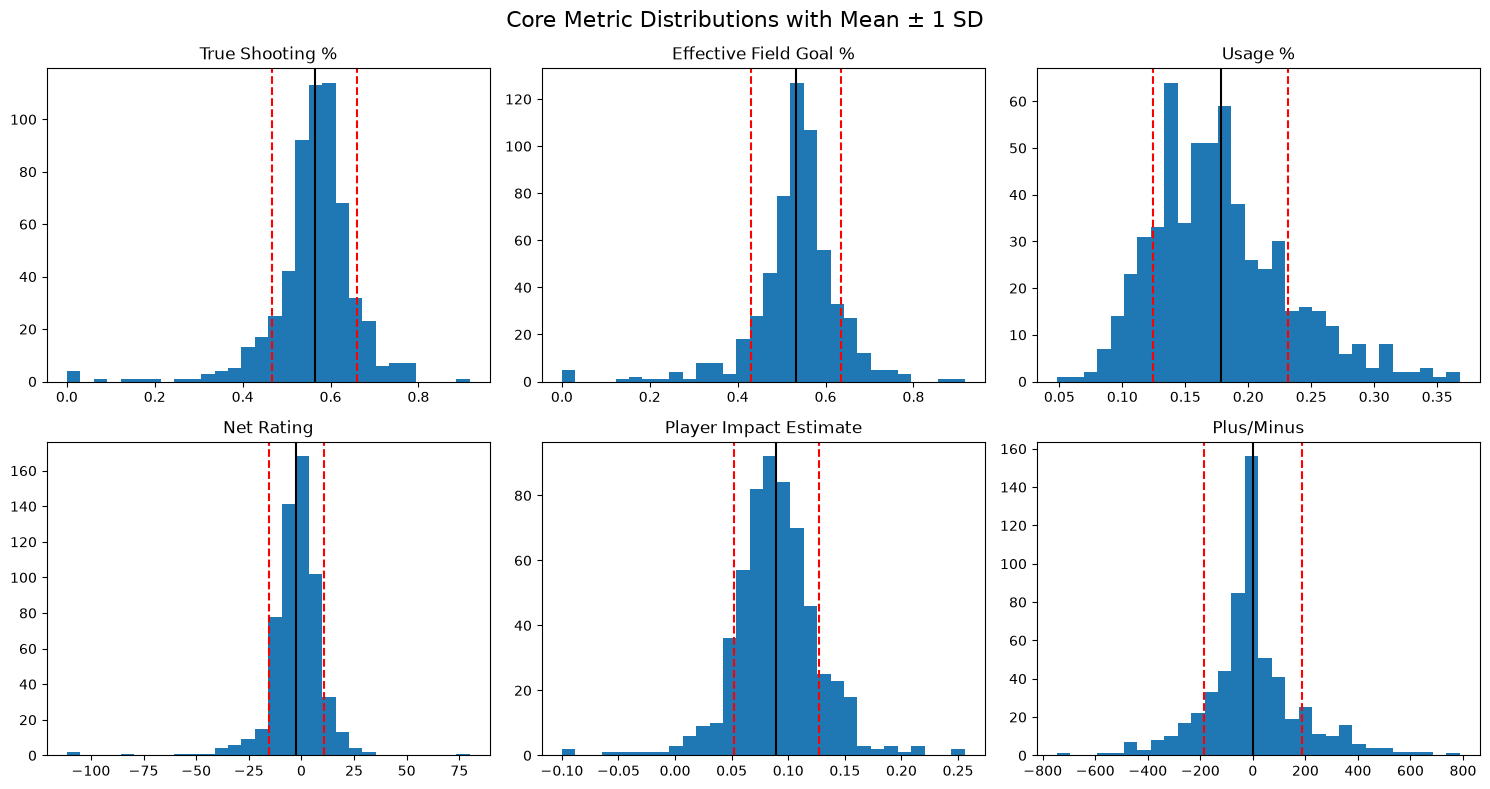

In [59]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

metrics = [
    (leaguestats_df, 'TS_PCT'),
    (leaguestats_df, 'EFG_PCT'),
    (leaguestats_df, 'USG_PCT'),
    (leaguestats_df, 'NET_RATING'),
    (leaguestats_df, 'PIE'),
    (leaguestats_base_df, 'PLUS_MINUS'),
]

readable_names = {
    'TS_PCT': 'True Shooting %',
    'EFG_PCT': 'Effective Field Goal %',
    'USG_PCT': 'Usage %',
    'NET_RATING': 'Net Rating',
    'PIE': 'Player Impact Estimate',
    'PLUS_MINUS': 'Plus/Minus',
}

for ax, (df, col) in zip(axes, metrics):
    mean_val = df[col].mean()
    std_val = df[col].std()
    ax.hist(df[col], bins=30)
    ax.axvline(mean_val, color='black', linestyle='-')
    ax.axvline(mean_val + std_val, color='red', linestyle='--')
    ax.axvline(mean_val - std_val, color='red', linestyle='--')
    ax.set_title(readable_names.get(col, col))
    fig.suptitle('Core Metric Distributions with Mean ± 1 SD', fontsize=16)

plt.tight_layout()
plt.show()

### **Get Active Player List**

- Pulls the full static player table (`id`, `full_name`, `is_active`, etc.) — no stats, just names and IDs, used to look up `PLAYER_ID` for other endpoints
- Filtered down to `is_active == True` — cuts 5,103 total players (including decades of retirees) down to the 530 currently active, since only current players are relevant to this analysis

In [60]:
players = players_module.get_players()
players_df = pd.DataFrame(players)
active_players_df = players_df[players_df['is_active'] == True]
display(active_players_df.head())
len(active_players_df)


,id,full_name,first_name,last_name,is_active
10,1630173,Precious Achiuwa,Precious,Achiuwa,True
22,203500,Steven Adams,Steven,Adams,True
24,1628389,Bam Adebayo,Bam,Adebayo,True
29,1630534,Ochai Agbaji,Ochai,Agbaji,True
41,1630583,Santi Aldama,Santi,Aldama,True


530

### **Test PlayerAwards on LeBron**

- `PlayerAwards` is a per-player endpoint — no bulk/season-wide mode — so it's tested here on one well-documented player (LeBron James) before looping it across the full player list
- Purpose: inspect the actual response structure before building any filtering logic on top of it

In [61]:
lebron_ID = 2544

sample_awards = playerawards.PlayerAwards(player_id=lebron_ID).get_data_frames()[0]  # LeBron James
sample_awards.columns.tolist()


['PERSON_ID',
 'FIRST_NAME',
 'LAST_NAME',
 'TEAM',
 'DESCRIPTION',
 'ALL_NBA_TEAM_NUMBER',
 'SEASON',
 'MONTH',
 'WEEK',
 'CONFERENCE',
 'TYPE',
 'SUBTYPE1',
 'SUBTYPE2',
 'SUBTYPE3']

### **Preview Award Rows**

- Shows the first few rows of the raw awards table — name, season, and award description columns
- First-glance check only; not representative of the full award history (see next cell for the complete picture)

In [62]:
sample_awards[['FIRST_NAME', 'LAST_NAME', 'SEASON', 'DESCRIPTION']].sample(10)

,FIRST_NAME,LAST_NAME,SEASON,DESCRIPTION
35,LeBron,James,2011-12,NBA All-Star
36,LeBron,James,2012-13,NBA All-Star
24,LeBron,James,2022-23,All-NBA
94,LeBron,James,2014-15,NBA Player of the Month
119,LeBron,James,2007-08,NBA Player of the Week
10,LeBron,James,2008-09,All-NBA
91,LeBron,James,2013-14,NBA Player of the Month
169,LeBron,James,2019-20,NBA Player of the Week
50,LeBron,James,2005-06,NBA All-Star Most Valuable Player
0,LeBron,James,2008-09,All-Defensive Team


### **List All Distinct Award Types**

- Returns every unique value in `DESCRIPTION` across this player's full award history, not just the first few rows
- Needed to see the exact wording used for All-Star/All-NBA selections (`'NBA All-Star'`, `'All-NBA'`, etc.) before writing a filter — award names are inconsistent enough (e.g. `'NBA All-Star'` vs. `'NBA All-Star Most Valuable Player'`) that guessing the exact strings would be unreliable

In [63]:
sample_awards['DESCRIPTION'].unique()

<StringArray>
[                                'All-Defensive Team',
                                            'All-NBA',
                                    'All-Rookie Team',
                                       'NBA All-Star',
                  'NBA All-Star Most Valuable Player',
                                       'NBA Champion',
                        'NBA Cup All-Tournament Team',
                       'NBA Cup Most Valuable Player',
                    'NBA Finals Most Valuable Player',
                           'NBA Most Valuable Player',
                            'NBA Player of the Month',
                             'NBA Player of the Week',
                            'NBA Rookie of the Month',
                             'NBA Rookie of the Year',
 'NBA Sporting News Most Valuable Player of the Year',
               'NBA Sporting News Rookie of the Year',
                               'Olympic Bronze Medal',
                                 'Olympic Gold Meda

### **Narrow the Field Before Checking Awards**

- Joins the active player list to season `MIN`/`GP` (via `.join()` on player ID) and filters to players with `MIN >= 500`
- Purpose: `PlayerAwards` requires one API call per player — pulling all 530 active players individually is slow and mostly wasted on players who clearly never had a realistic shot at an award. This is a loose, generous pre-filter to cut wasted calls, not a definition of "star" — the actual star/not-star label still comes entirely from the awards check in the next cell

In [64]:
active_indexed = active_players_df.set_index('id')
stats_indexed = leaguestats_base_df.set_index('PLAYER_ID')[['MIN', 'GP']]

candidates_df = active_indexed.join(stats_indexed, how='inner')
candidates_df = candidates_df[candidates_df['MIN'] >= 500].reset_index()
len(candidates_df)

374

### **Build the Star Player List**

- Loops through every candidate, pulls their award history, and flags them as a "star" if any award description contains `'All-Star'` or `'All-NBA'` — the same filter logic validated earlier on LeBron
- `try/except` prevents one failed request from killing the whole loop; a failure is treated as "not a star" and logged rather than stopping execution
- `time.sleep(0.8)` paces requests to avoid getting rate-limited by `stats.nba.com`
- Result: `star_status_df` (every candidate with a True/False label) and `star_players_df` (filtered to just the True rows) — this is the reputation-based "star" definition used for the rest of the analysis

In [65]:
results = []

for i, player in enumerate(candidates_df.itertuples()):
    if i % 25 == 0:
        print(f"Processed {i}/{len(candidates_df)}...")
    try:
        awards = playerawards.PlayerAwards(player_id=player.id).get_data_frames()[0]
        is_star = (
            awards['DESCRIPTION'].str.contains('All-Star') |
            awards['DESCRIPTION'].str.contains('All-NBA')
        ).any()
    except Exception as e:
        print(f"failed for {player.full_name}: {e}")
        is_star = False

    results.append({'PLAYER_ID': player.id, 'PLAYER_NAME': player.full_name, 'is_star': is_star})
    time.sleep(0.5)

star_status_df = pd.DataFrame(results)
star_players_df = star_status_df[star_status_df['is_star']]
len(star_players_df)

Processed 0/374...
Processed 25/374...
Processed 50/374...
Processed 75/374...
Processed 100/374...
Processed 125/374...
Processed 150/374...
Processed 175/374...
Processed 200/374...
Processed 225/374...
Processed 250/374...
Processed 275/374...
Processed 300/374...
Processed 325/374...
Processed 350/374...


64

### **Pull League-Wide Clutch Stats**

- Same `Advanced` mode used for season stats, but from `LeagueDashPlayerClutch` instead — restricts the data to clutch situations only (last 5 minutes, score within 5 points, per `clutch_time`/`point_diff`/`ahead_behind` parameters)
- Gives clutch-specific `TS_PCT` and the other core metrics, to be compared against each player's season-long numbers

In [66]:
clutch_df = leaguedashplayerclutch.LeagueDashPlayerClutch(
    season="2025-26",
    season_type_all_star="Regular Season",
    per_mode_detailed="PerGame",
    clutch_time="Last 5 Minutes",
    point_diff="5",
    ahead_behind="Ahead or Behind",
    measure_type_detailed_defense="Advanced"
).get_data_frames()[0]

clutch_df.shape

(492, 80)

### **Compare Season vs. Clutch Performance**

- Joins each star player's clutch `TS_PCT` and season `TS_PCT` together (via `PLAYER_ID`) and computes `TS_DIFF` = clutch minus season
- Negative `TS_DIFF` means a player shoots worse in the clutch than their season average; positive means better
- Sorted ascending, so the biggest clutch decliners surface at the top

In [67]:
season_ts = leaguestats_df.set_index('PLAYER_ID')[['TS_PCT']].rename(columns={'TS_PCT': 'SEASON_TS_PCT'})
clutch_ts = clutch_df.set_index('PLAYER_ID')[['TS_PCT']].rename(columns={'TS_PCT': 'CLUTCH_TS_PCT'})

comparison_df = (
    star_players_df.set_index('PLAYER_ID')
    .join(clutch_ts, how='inner')
    .join(season_ts, how='inner')
)
comparison_df['TS_DIFF'] = comparison_df['CLUTCH_TS_PCT'] - comparison_df['SEASON_TS_PCT']
comparison_df = comparison_df.reset_index().sort_values('TS_DIFF')

comparison_df[['PLAYER_NAME', 'SEASON_TS_PCT', 'CLUTCH_TS_PCT', 'TS_DIFF']]

,PLAYER_NAME,SEASON_TS_PCT,CLUTCH_TS_PCT,TS_DIFF
32,Al Horford,0.554,0.335,-0.219
34,Jaren Jackson Jr.,0.576,0.357,-0.219
52,Domantas Sabonis,0.590,0.396,-0.194
5,Paolo Banchero,0.566,0.376,-0.190
56,Klay Thompson,0.541,0.385,-0.156
30,Jrue Holiday,0.573,0.419,-0.154
38,Zach LaVine,0.614,0.460,-0.154
2,Giannis Antetokounmpo,0.658,0.506,-0.152
21,Joel Embiid,0.605,0.462,-0.143
19,Jalen Duren,0.688,0.556,-0.132


### **Attach Clutch Shot Attempts (Sample-Size Check)**

- Pulls clutch stats a second time in `Base`/`Totals` mode specifically to get `CLUTCH_FGA` — total clutch shot attempts, not available in `Advanced` mode
- Joined onto `comparison_df` to catch the same small-sample problem found in the season data (e.g. a player with only 2 clutch attempts can show a mathematically extreme `TS_PCT` that isn't meaningful)
- Wrapped in `if 'CLUTCH_FGA' not in comparison_df.columns:` so the cell is safe to re-run without erroring on a duplicate column

In [68]:
if 'CLUTCH_FGA' not in comparison_df.columns:
    clutch_base_df = leaguedashplayerclutch.LeagueDashPlayerClutch(
        season="2025-26",
        season_type_all_star="Regular Season",
        per_mode_detailed="Totals",
        clutch_time="Last 5 Minutes",
        point_diff="5",
        ahead_behind="Ahead or Behind",
        measure_type_detailed_defense="Base"
    ).get_data_frames()[0]

    clutch_attempts = clutch_base_df.set_index('PLAYER_ID')[['FGA']].rename(columns={'FGA': 'CLUTCH_FGA'})
    comparison_df = comparison_df.set_index('PLAYER_ID').join(clutch_attempts, how='inner').reset_index()

comparison_df[['PLAYER_NAME', 'CLUTCH_FGA', 'SEASON_TS_PCT', 'CLUTCH_TS_PCT', 'TS_DIFF']].sort_values('CLUTCH_FGA')

,PLAYER_NAME,CLUTCH_FGA,SEASON_TS_PCT,CLUTCH_TS_PCT,TS_DIFF
63,Mike Conley,2,0.517,1.310,0.793
2,Domantas Sabonis,5,0.590,0.396,-0.194
52,Jayson Tatum,5,0.541,0.589,0.048
14,Kevin Love,5,0.568,0.460,-0.108
38,Andre Drummond,7,0.539,0.543,0.004
26,Jarrett Allen,12,0.669,0.614,-0.055
62,Draymond Green,13,0.540,0.825,0.285
21,Brook Lopez,13,0.552,0.468,-0.084
25,Anthony Davis,15,0.551,0.486,-0.065
58,Tyler Herro,16,0.602,0.676,0.074


### **Test Candidate Clutch-Attempt Cutoffs**

- Same approach used earlier for season-long `FGA` — counts how many of the 64 star players survive at each candidate minimum-attempt threshold
- Purpose: pick a cutoff that removes small-sample noise (e.g. Mike Conley's 2-attempt, 1.310 TS_PCT outlier) without discarding too much of the star group

In [69]:
for cutoff in [10, 20, 30, 40, 50]:
    kept = (comparison_df['CLUTCH_FGA'] >= cutoff).sum()
    print(f"Clutch FGA >= {cutoff}: {kept} players kept out of {len(comparison_df)}")

Clutch FGA >= 10: 59 players kept out of 64
Clutch FGA >= 20: 47 players kept out of 64
Clutch FGA >= 30: 37 players kept out of 64
Clutch FGA >= 40: 26 players kept out of 64
Clutch FGA >= 50: 23 players kept out of 64


### **Final Filtered Comparison Table**

- Applies the chosen cutoff (`CLUTCH_FGA >= 30`) to remove the noisiest, lowest-sample players from the comparison
- This is the actual answer to "who's performing well/badly in the clutch" — sorted by `TS_DIFF`, biggest decliners at the top


In [70]:
comparison_filtered = comparison_df[comparison_df['CLUTCH_FGA'] >= 30]  # adjust based on the counts above
comparison_filtered.sort_values('TS_DIFF')[['PLAYER_NAME', 'CLUTCH_FGA', 'SEASON_TS_PCT', 'CLUTCH_TS_PCT', 'TS_DIFF']]

,PLAYER_NAME,CLUTCH_FGA,SEASON_TS_PCT,CLUTCH_TS_PCT,TS_DIFF
1,Jaren Jackson Jr.,37,0.576,0.357,-0.219
3,Paolo Banchero,80,0.566,0.376,-0.190
7,Giannis Antetokounmpo,39,0.658,0.506,-0.152
8,Joel Embiid,40,0.605,0.462,-0.143
10,Zion Williamson,51,0.644,0.515,-0.129
12,Kawhi Leonard,36,0.629,0.511,-0.118
13,Brandon Ingram,66,0.573,0.460,-0.113
17,Alperen Sengun,82,0.569,0.472,-0.097
18,Bam Adebayo,36,0.551,0.457,-0.094
20,Pascal Siakam,56,0.562,0.472,-0.090


### **Full Star + Clutch Join (Reference Table)**

- Joins the complete `star_players_df` and `clutch_df` tables together on `PLAYER_ID`, keeping all clutch columns (not just `TS_PCT`) for all 64 stars
- Broader reference table — not used directly downstream, but available if a metric beyond `TS_PCT` needs checking later

In [71]:
star_indexed = star_players_df.set_index('PLAYER_ID')
clutch_indexed = clutch_df.set_index('PLAYER_ID')

star_clutch_df = star_indexed.join(clutch_indexed, how='inner', lsuffix='_star', rsuffix='_clutch')
star_clutch_df = star_clutch_df.reset_index()
star_clutch_df.shape

(64, 82)

### **Top 10 Clutch Improvers**

- Same `comparison_filtered` table, sorted descending instead of ascending — surfaces the players whose clutch `TS_PCT` is highest relative to their season average

In [73]:
comparison_filtered.sort_values('TS_DIFF', ascending=False)[
    ['PLAYER_NAME', 'CLUTCH_FGA', 'SEASON_TS_PCT', 'CLUTCH_TS_PCT', 'TS_DIFF']
].head(10)

,PLAYER_NAME,CLUTCH_FGA,SEASON_TS_PCT,CLUTCH_TS_PCT,TS_DIFF
59,James Harden,60,0.610,0.685,0.075
57,Anthony Edwards,85,0.617,0.687,0.070
56,Jamal Murray,92,0.622,0.686,0.064
55,DeMar DeRozan,48,0.594,0.651,0.057
53,Jalen Johnson,64,0.581,0.631,0.050
51,Scottie Barnes,34,0.577,0.622,0.045
49,Devin Booker,61,0.585,0.625,0.040
50,Deni Avdija,62,0.600,0.640,0.040
48,LeBron James,33,0.594,0.631,0.037
47,Lauri Markkanen,38,0.608,0.644,0.036


### **Investigate a Top Improver's Matchup Data**

- Pulls season-long defender matchup data for James Harden (top clutch improver) via `LeagueSeasonMatchups` — a bulk, season-level endpoint, unlike the per-game-only `BoxScoreMatchupsV3` named in the original proposal
- Sorted by `MATCHUP_TIME_SEC` (the real numeric time field) rather than `MATCHUP_MIN`, which is a string ("9:51") that would sort incorrectly as text
- This is season-wide matchup data, not filtered to clutch situations specifically — the NBA API doesn't support that split for this endpoint, so it's a proxy for "who generally guards him," not a literal clutch-matchup breakdown

In [74]:
harden_id = comparison_filtered[comparison_filtered['PLAYER_NAME'] == 'James Harden']['PLAYER_ID'].values[0]

harden_matchups_df = leagueseasonmatchups.LeagueSeasonMatchups(
    season="2025-26",
    off_player_id_nullable=harden_id
).get_data_frames()[0]

harden_matchups_df.sort_values('MATCHUP_TIME_SEC', ascending=False)[
    ['DEF_PLAYER_NAME', 'GP', 'MATCHUP_MIN', 'PARTIAL_POSS', 'MATCHUP_FGM', 'MATCHUP_FGA', 'MATCHUP_FG_PCT']
].head(10)

,DEF_PLAYER_NAME,GP,MATCHUP_MIN,PARTIAL_POSS,MATCHUP_FGM,MATCHUP_FGA,MATCHUP_FG_PCT
1,Jaylen Wells,3,24:55,116.9,6,16,0.375
2,Dyson Daniels,4,24:14,110.5,8,16,0.500
0,Naji Marshall,4,22:48,118.7,11,16,0.688
3,Davion Mitchell,4,21:27,104.3,6,10,0.600
7,Toumani Camara,2,13:46,61.9,5,7,0.714
9,Marcus Smart,3,13:45,59.0,5,10,0.500
8,Paolo Banchero,2,13:07,60.8,10,13,0.769
5,Ausar Thompson,3,12:52,62.4,3,10,0.300
4,Sion James,3,12:33,65.0,9,19,0.474
6,Cason Wallace,2,12:28,62.3,6,10,0.600
